In [95]:
from functools import reduce
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns

In [96]:
LLM_model_tag = 'llama3'
subsample_size = 100

In [97]:
random_sampling = {
    'alpaca-safer-100': {'count': 10}
}
optimized_sampling = {}
# optimized_sampling = {
#     'Double SVD (Best)': { 'file_path': f'../../evaluation-artifacts/{LLM_model_tag}/alpaca-svd-{subsample_size}/alpaca-double-svd-{subsample_size}-high/BeaverTails-Evaluation.csv'},
#     'Harm Model Selection (Best)':  {'file_path': f'../../evaluation-artifacts/{LLM_model_tag}/harm-selection-{subsample_size}-low/BeaverTails-Evaluation.csv'},
# }

### Load Baseline

In [98]:
# baseline_file = f'../../evaluation-artifacts/{LLM_model_tag}/alpaca-small/BeaverTails-Evaluation.csv'
# alpaca_small_df = pd.read_csv(baseline_file)
alpaca_small_df = None

### Load Random sampling results

In [99]:
for exp_key, param_dict in random_sampling.items():
    count = param_dict['count']
    csv_files = [f'../../evaluation-artifacts/{LLM_model_tag}/{exp_key}/{exp_key}-dataset{i}/BeaverTails-Evaluation.csv' for i in range(count)]
    dfs = [pd.read_csv(file) for file in csv_files]
    mean_harmfulness_scores = []
    for i, df in enumerate(dfs):
        #print(dfs['Harmfulness Score'].mean(axis=1))
        mean_harmfulness_scores.append(df['Harmfulness Score'].mean())
    random_sampling[exp_key]['harm_scores'] = mean_harmfulness_scores

### Load optimized sampling results

In [100]:
for exp_string, param_dict in optimized_sampling.items():
    file_path = param_dict['file_path']
    df = pd.read_csv(file_path)
    df.rename(columns={"Harmfulness Score": f"Harmfulness_Score"}, inplace=True)
    optimized_sampling[exp_string]['harm_score'] = df['Harmfulness_Score'].mean() 

### Visualize results

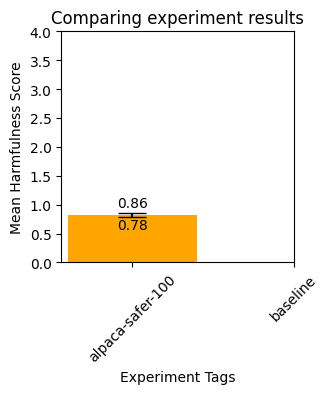

In [101]:
plt.figure(figsize=(max(3,2.5 * len(optimized_sampling) + len(random_sampling)), 3))

#Plot optimized sampling
for i, exp_string in enumerate(optimized_sampling):
    harm_score = optimized_sampling[exp_string]['harm_score'] 
    plt.bar(i+1, harm_score, )
    plt.text(i+1,harm_score + 0.1, f"{harm_score:.2f}", ha='center')

#Plot random sampling
for i, exp_tag in enumerate(random_sampling):
    harm_scores = random_sampling[exp_key]['harm_scores']
    plt.bar(i+1+len(optimized_sampling), np.mean(harm_scores), yerr=np.std(harm_scores), capsize=10, color="orange")
    plt.text(i+1+len(optimized_sampling), np.mean(harm_scores) + np.std(harm_scores) + 0.1, 
         f"{np.mean(harm_scores) + np.std(harm_scores):.2f}", ha='center')
    plt.text(i+1+len(optimized_sampling), np.mean(harm_scores) - np.std(harm_scores) - 0.2, 
         f"{np.mean(harm_scores) - np.std(harm_scores):.2f}", ha='center')

#plot baseline
if alpaca_small_df:
    plt.bar(len(optimized_sampling) + len(random_sampling) + 1, alpaca_small_df['Harmfulness_Score'].mean(), color="blue")
    plt.text(len(optimized_sampling) + len(random_sampling) + 1, alpaca_small_df['Harmfulness_Score'].mean() + 0.1, 
            f"{alpaca_small_df['Harmfulness_Score'].mean():.2f}", ha='center')

plt.xticks(np.arange(1,len(optimized_sampling) + len(random_sampling) + 2), [exp_string for exp_string in optimized_sampling] + [exp_string for exp_string in random_sampling] + ['baseline'], rotation=45)
plt.ylim(0,4)
plt.ylabel("Mean Harmfulness Score")
plt.xlabel("Experiment Tags")
plt.title("Comparing experiment results")
plt.show()